<a href="https://colab.research.google.com/github/stepkabeast/practice_terrain_classifier/blob/master/SA-ImageRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy
from tensorflow import keras
from keras.constraints import MaxNorm
from keras.utils import to_categorical as tc

In [2]:
seed = 21

In [3]:
from keras.datasets import cifar10

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [7]:
model = keras.Sequential()

In [8]:
model.add(keras.layers.Conv2D(32, 3, input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(64, 3, padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Flatten())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Dense(class_num, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,962 (1.50 MB)

 Trainable params: 393,322 (1.50 MB)

 Non-trainable params: 640 (2.50 KB)

None


In [9]:
numpy.random.seed(seed)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=25, batch_size=64)
model.save('diplom_model_cifar10.h5')

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 358s 452ms/step - accuracy: 0.3645 - loss: 1.8040 - val_accuracy: 0.5411 - val_loss: 1.2911
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 383s 454ms/step - accuracy: 0.5842 - loss: 1.1714 - val_accuracy: 0.6595 - val_loss: 0.9735
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 350s 448ms/step - accuracy: 0.6537 - loss: 0.9909 - val_accuracy: 0.7287 - val_loss: 0.7880
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 380s 445ms/step - accuracy: 0.6918 - loss: 0.8912 - val_accuracy: 0.7437 - val_loss: 0.7368
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 357s 456ms/step - accuracy: 0.7178 - loss: 0.8191 - val_accuracy: 0.7440 - val_loss: 0.7310
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 351s 449ms/step - accuracy: 0.7346 - loss: 0.7666 - val_accuracy: 0.7618 - val_loss: 0.6740
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 345s 442ms/step - accuracy: 0.7505 - loss: 0.7314 - val_accuracy: 0.7526 - val_loss: 0.7119
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 355s 454ms/step - accuracy: 0.7626 -

In [10]:
model.evaluate(X_test, y_test, verbose=0)

scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))


Accuracy: 81.79%


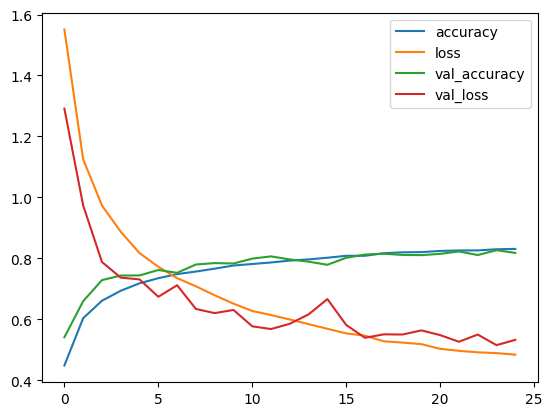

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot()
plt.show()

Загрузите одно или несколько изображений (лучше 32x32, но можно и больше — они будут изменены)


Saving bird.png to bird.png
Saving dog.jpg to dog.jpg
Saving ship.png to ship.png
Saving frog.png to frog.png
Saving cat.png to cat.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


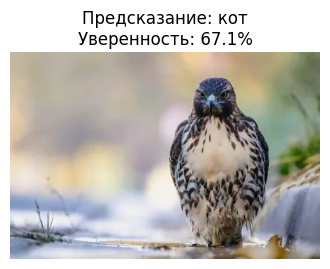

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


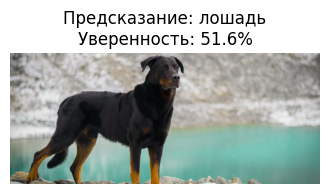

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


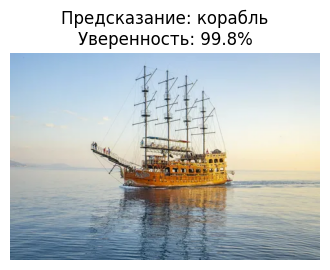

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


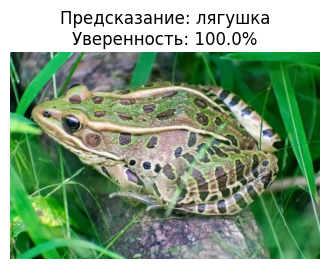

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


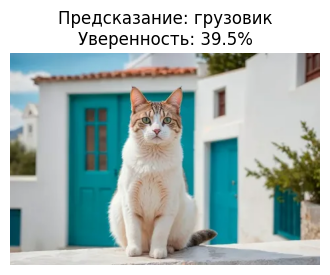

In [12]:
import numpy as np
from keras.preprocessing import image
from google.colab import files
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

# Словарь с названиями классов CIFAR-10
cifar10_classes = {
    0: 'самолёт',     1: 'автомобиль',   2: 'птица',
    3: 'кот',         4: 'олень',        5: 'собака',
    6: 'лягушка',     7: 'лошадь',       8: 'корабль',
    9: 'грузовик'
}

print("Загрузите одно или несколько изображений (лучше 32x32, но можно и больше — они будут изменены)")
uploaded = files.upload()

# Проходим по каждому загруженному файлу
for filename in uploaded.keys():
    # Открываем изображение
    img_pil = Image.open(filename)

    # Изменяем размер до 32x32 — как у CIFAR-10
    img_resized = img_pil.resize((32, 32), Image.Resampling.LANCZOS)

    # Конвертируем в массив
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)  # Добавляем batch-размер
    img_array /= 255.0  # Нормализация, как при обучении

    # Предсказание
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100

    # Визуализация
    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil)
    plt.title(f"Предсказание: {cifar10_classes[predicted_class]}\n"
              f"Уверенность: {confidence:.1f}%", fontsize=12)
    plt.axis('off')
    plt.show()